# Elliptic Curves Pseudo Random Number Generators

# Dependencies

In [78]:
from math import erfc, sqrt
from numpy import set_printoptions
from scipy.special import gammaincc
from tabulate import tabulate
import random
import matplotlib.pyplot as plt
from ipynb.fs.full.utils_ntheory import *
from ipynb.fs.full.utils_ecpsrng import *
from ipynb.fs.full.utils_ecurves import *
from ipynb.fs.full.utils_nist import *

set_printoptions(precision=4)

## Setting a timer

In [80]:
import time
t_0 = time.time()

### Tu código aquí

t_1 = time.time()
total = t_1 - t_0
print(total)

0.0


# Bitcoin Curve PSRN

In [82]:
E = [0,7] #represents the elliptic curve y^2 = x^3 + 7
p = 31 #the true value is bigger
G = [11, 25] #a point on the elliptic curve
L = generateCurve(E, p)

In [83]:
U =  L[8] #another point on the curve, representng the seed
PointsLinear = linearGenerator(E, p, G, U)
print(PointsLinear)

[[5, 15], [4, 28], [1, 15], [20, 28], [7, 28], [0, 21], [25, 15]]


In [84]:
print(pointToLastBits("O", 3))
print(pointToLastBits([20, 28], 1))
print(pointToBitMod([20, 28]))

[0]
[[0], [0]]
0


In [85]:
Gen1 = [pointToLastBits(Q, 1) for Q in PointsLinear]
print(Gen1)

sums = [i[0] + i[1] for i in PointsLinear]
print(sums)

Gen2 = pointToBit(PointsLinear)
print(Gen2)

[[[1], [1]], [[0], [0]], [[1], [1]], [[0], [0]], [[1], [0]], [[0], [1]], [[1], [1]]]
[20, 32, 16, 48, 35, 21, 40]
[0, 0, 0, 0, 1, 1, 0]


In [86]:
nested = [i[0] + i[1] for i in Gen1]
flat = [item for sublist in nested for item in sublist]
print(flat)  # Output: [1, 2, 3, 4, 5, 6]

[1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1]


# Frequency test

In [88]:
s = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(k) for k in s]
n = 100
alpha = 0.01
frequencyTest(L, 100)

0.10959858339911599

# Frequency test M-Blocks

In [90]:
bits = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(b) for b in bits]
n = len(L)
M = 10
frequencyBlockTest(L, M, n)

0.7064384496412808

# Runs test

In [92]:
bits = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(b) for b in bits]
n = len(L)
t = 0.2
sig = 0.01

In [93]:
runsTest(L, n)

0.5007979178870902

# Tabulate Results

In [95]:
bits = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(b) for b in bits]
n = len(L)
print(L)

[1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0]


In [96]:
testResults(L, n)

+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       |  0.109599 |
+----------------------+-----------+
| Frequency block test |  0.706438 |
+----------------------+-----------+
| Runs                 |  0.500798 |
+----------------------+-----------+


# Model Testing

In [98]:
def generateLinSeq(E, p, i, s):
    """
    Generates a bit sequence using the linear generator model for the elliptic curve (E, p)
    with initial point G and seed U.
    """
    L = generateCurve(E, p)
    print("Model size:", len(L))
    points = linearGenerator(E, p, L[i], L[s])
    return pointToBit(points)

def testElliptic(E, p, i, s):
    """
    tests the randomicity of a sequence of bits for the curve (E, p) and 
    """
    bits = generateLinSeq(E, p, i, s)
    n = len(bits)
    print("Bit sequence length:", len(bits))
    testResults(bits, n)

In [99]:
testElliptic([0,7], 7901, 5, 20)

Model size: 7902
Bit sequence length: 2634
+----------------------+------------+
| Test                 |    p-value |
+======================+============+
| Frequency test       | 1          |
+----------------------+------------+
| Frequency block test | 0.913153   |
+----------------------+------------+
| Runs                 | 0.00182367 |
+----------------------+------------+


In [100]:
testElliptic([0,7], 1523, 100, 27)

Model size: 1524
Bit sequence length: 127
+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       |  0.929292 |
+----------------------+-----------+
| Frequency block test |  0.989622 |
+----------------------+-----------+
| Runs                 |  0.928732 |
+----------------------+-----------+


In [101]:
testElliptic([0,7], 1523, 100, 1)

Model size: 1524
Bit sequence length: 127
+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       |  0.534501 |
+----------------------+-----------+
| Frequency block test |  0.580913 |
+----------------------+-----------+
| Runs                 |  0.631675 |
+----------------------+-----------+


In [102]:
testElliptic([0,7], 1523, 25, 1)

Model size: 1524
Bit sequence length: 508
+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       | 0.657275  |
+----------------------+-----------+
| Frequency block test | 0.0777794 |
+----------------------+-----------+
| Runs                 | 0.540106  |
+----------------------+-----------+


# Bitcoin curve with big primes

+-------------+------------+------------+---------------------+--------------+
| Test        |   accepted |   rejected |   proportion passed | confidence   |
+=============+============+============+=====================+==============+
| frequencies |        957 |         43 |               0.957 | True         |
+-------------+------------+------------+---------------------+--------------+
| blocks      |        940 |         60 |               0.94  | True         |
+-------------+------------+------------+---------------------+--------------+
| runs        |        949 |         51 |               0.949 | True         |
+-------------+------------+------------+---------------------+--------------+


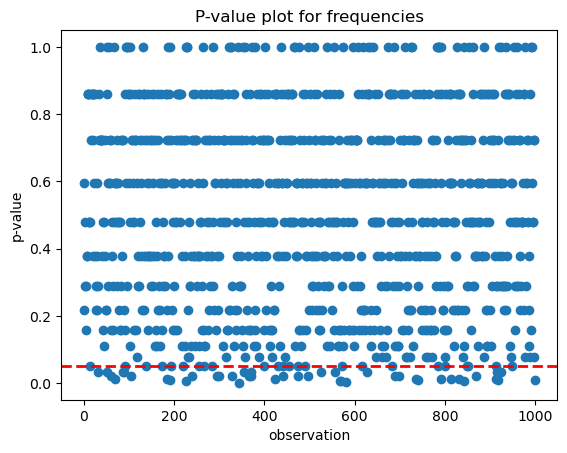

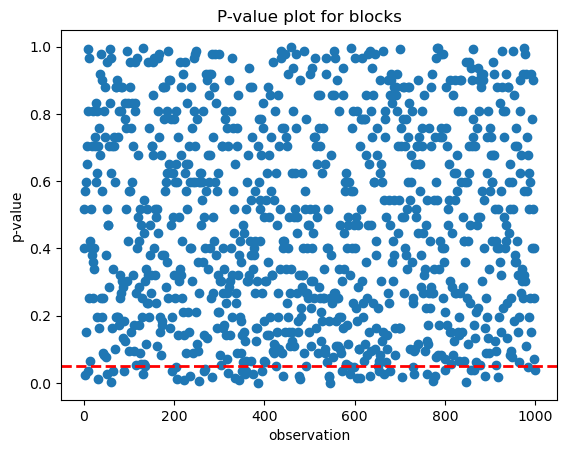

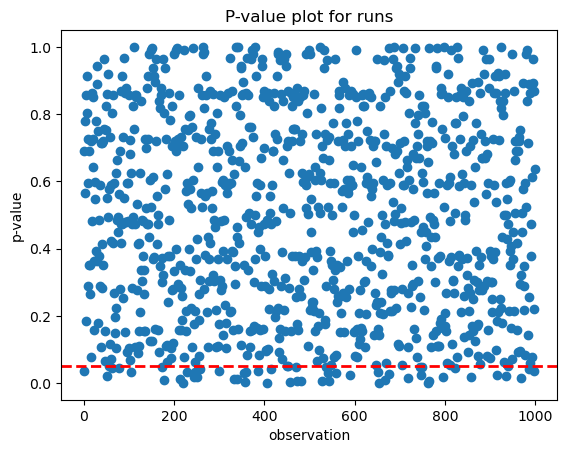

In [104]:
E = [0,7] #represents the elliptic curve y^2 = x^3 + 7
p = 2**256 - 2**32 - 977
x = 0x79BE667EF9DCBBAC55A06295CE870B07029BFCDB2DCE28D959F2815B16F81798
y = 0x483ADA7726A3C4655DA4FBFC0E1108A8FD17B448A68554199C47D08FFB10D4B8
G = [x, y]
n = 128
m = 1000
M = 20
alpha = 0.05

S = generateKSequences(E, p, G, n, m)
data = pVals(S, n, M)

metrics(data, m, alpha)

plotPvals(data, "frequencies", m, alpha)
plotPvals(data, "blocks", m, alpha)
plotPvals(data, "runs", m, alpha)